<h1><font color="#113D68" size=6>Deep Learning en Python con PyTorch</font></h1>

<h1><font color="#113D68" size=5>Parte 3. Multilayer Perceptron</font></h1>

<h1><font color="#113D68" size=4>7. Proyecto de clasificación binaria</font></h1>

<br><br>
<div style="text-align: right">
<font color="#113D68" size=3>Manuel Castillo Cara</font><br>

</div>

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
More information about [Manuel Castillo-Cara](https://www.manuelcastillo.eu/)

<div class="alert alert-block alert-info">

<i class="fa fa-info-circle" aria-hidden="true"></i>
Puedes ver más cursos de Inteligencia Artificial, Machine Learning y Deep Learning en mi [página web](https://www.manuelcastillo.eu/udemy/)


---

<a id="indice"></a>
<h2><font color="#004D7F" size=5>Índice</font></h2>

* [0. Contexto](#section0)
* [1. Descripción del Conjunto de Datos](#section1)
* [2. Importar librerías y cargar el dataset](#section2)
* [3. Ajuste de capas y neuronas](#section3)
    * [3.1. Evaluar una topología más ancha](#section3.1)
    * [3.2. Evaluar una topología más profunda](#section3.2)
* [4. Comparar Modelos con Validación Cruzada](#section4)
* [5. Reentrenar el Modelo Final](#section5)

---
<a id="section0"></a>
# <font color="#004D7F" size=6> 0. Contexto</font>

Este capítulo te mostrará cómo usar PyTorch para desarrollar y evaluar modelos de redes neuronales para problemas de clasificación binaria.

Después de completar este capítulo, sabrás:
- Cómo cargar datos de entrenamiento y hacerlos disponibles para PyTorch
- Cómo diseñar y entrenar una red neuronal
- Cómo evaluar el rendimiento de un modelo de red neuronal utilizando validación cruzada k-fold
- Cómo ejecutar un modelo en modo de inferencia
- Cómo crear una curva de características operativas del receptor (ROC) para un modelo de clasificación binaria

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section1"></a>
# <font color="#004D7F" size=6>1. Descripción del Conjunto de Datos</font>

Conjunto de datos: Sonar

- Características:
  - Describe retornos de sonar rebotando en diferentes superficies

  - 60 variables de entrada

  - Variables representan intensidad de retornos en diferentes ángulos

- Tipo de problema:
  - Clasificación binaria
  
  - Objetivo: diferenciar entre rocas y Minas

- Propiedades de los datos:
  - Variables continuas

  - Rango típico: 0 a 1

  - Variable de salida: 

    - "M" para minas

    - "R" para rocas

  - Necesidad de convertir salidas a enteros (1 y 0)

- Rendimiento esperado:
  - Usando validación cruzada

  - Precisión entre 84% y 88% para una red neuronal

Este conjunto de datos proporciona un buen punto de partida para practicar y evaluar modelos de clasificación binaria.

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Más información sobre el dataset [Sonar](https://archive.ics.uci.edu/ml/datasets/Connectionist+Bench+(Sonar,+Mines+vs.+Rocks))

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section2"></a>
# <font color="#004D7F" size=6>2. Importar librerías y cargar el dataset</font>

- Carga del conjunto de datos Sonar:

  - Formato del archivo: CSV

  - Nombre del archivo: `sonar.csv`

  - Ubicación: directorio local

- Estructura de los datos:
  - 60 variables de entrada (X)

  - 1 variable de salida (y)

- Método de carga recomendado: pandas

  - Razón: el archivo contiene datos mixtos (cadenas y números)

  - Pandas maneja mejor este tipo de datos mixtos que otras herramientas como NumPy

- Código para cargar los datos:

- Procesamiento adicional necesario:

  - Convertir etiquetas de cadena ("M" y "R") a valores numéricos (1 y 0)

In [1]:
# Descarga de datos (necesario en Colab): se guardan en ./Datasets
import os, urllib.request

os.makedirs('Datasets', exist_ok=True)
urls = {
    'sonar.csv':
        'https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv',
}
for nombre, url in urls.items():
    if not os.path.exists(f'Datasets/{nombre}'):
        urllib.request.urlretrieve(url, f'Datasets/{nombre}')

In [2]:
import copy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from sklearn.metrics import roc_curve
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder

data = pd.read_csv("Datasets/sonar.csv", header=None)
X = data.iloc[:, 0:60].astype(float)
y = data[60]
y

0      R
1      R
2      R
3      R
4      R
      ..
203    M
204    M
205    M
206    M
207    M
Name: 60, Length: 208, dtype: object

Preferencia: Etiquetas numéricas en lugar de cadenas

- Herramienta para conversión: `LabelEncoder()` de scikit-learn

- Función de `LabelEncoder()`:

  - Asigna cada etiqueta a un entero

  - En este caso, convierte las dos etiquetas a 0 y 1

- Proceso de conversión:

  1. Llamar a `fit()` para aprender las etiquetas disponibles
  
  2. Llamar a `transform()` para realizar la conversión

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Más información sobre [`LabelEncoder()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html).

In [3]:
encoder = LabelEncoder()
encoder.fit(y)
y = encoder.transform(y)
y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

- Puedes ver que las etiquetas se han convertido en 0 y 1. 

- A partir de `encoder.classes_`, sabes que 0 significa "M" y 1 significa "R". 

- En el contexto de la clasificación binaria, también se les llama las clases negativa y positiva, respectivamente.

In [4]:
print(encoder.classes_)  # 0 = M (mina), 1 = R (roca)

['M' 'R']


Ahora lo convertimos en tensores de PyTorch.

In [5]:
X = torch.tensor(X.values, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)
y

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
      

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section3"></a>
# <font color="#004D7F" size=6>3. Ajuste de capas y neuronas</font>

- Modelo más sencillo: 3 capas (una capa oculta)

- Parámetros en redes neuronales: llamados pesos

- Dilema de diseño:
  - Menos capas con más parámetros por capa

               vs.
  
  - Más capas con menos parámetros por capa

- Objetivo: Descubrir qué enfoque es más efectivo

Esta comparación ayudará a entender la relación entre la profundidad del modelo y su capacidad de aprendizaje.

<a id="section3.1"></a>
# <font color="#004D7F" size=5>3.1. Evaluar una topología más ancha</font>

- Definición: Un modelo con más parámetros por capa se llama "modelo más ancho"

- Datos de entrada: 60 características

- Objetivo: Predecir una variable binaria

- Propuesta de modelo ancho:
  - Una capa oculta

  - 180 neuronas en la capa oculta (3 veces las características de entrada)

- Este modelo tiene una estructura simple pero con una capa oculta amplia.

- La capa de salida usa la función de activación Sigmoid para producir una probabilidad entre 0 y 1.

In [6]:
class Wide(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(60, 180)
        self.act = nn.ReLU()
        self.output = nn.Linear(180, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.act(self.hidden(x))
        x = self.sigmoid(self.output(x))
        return x

<a id="section3.2"></a>
# <font color="#004D7F" size=5>3.2. Evaluar una topología más profunda</font>

Problema: Clasificación binaria

- Requisitos de la salida:
  - Vector de longitud 1

  - Valor entre 0 y 1 (interpretable como probabilidad o confianza)

- Definición: Un modelo con más capas se llama "modelo más profundo"

- Propuesta de modelo profundo:

  - Tres capas ocultas

  - 60 neuronas en cada capa oculta

- Este modelo mantiene el mismo número total de neuronas que el modelo ancho, pero distribuidas en más capas.

- La capa final sigue usando Sigmoid para producir una salida entre 0 y 1.

In [7]:
class Deep(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(60, 60)
        self.act1 = nn.ReLU()
        self.layer2 = nn.Linear(60, 60)
        self.act2 = nn.ReLU()
        self.layer3 = nn.Linear(60, 60)
        self.act3 = nn.ReLU()
        self.output = nn.Linear(60, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.act1(self.layer1(x))
        x = self.act2(self.layer2(x))
        x = self.act3(self.layer3(x))
        x = self.sigmoid(self.output(x))
        return x

- Los parámetros de cada modelo se devuelven con `model1.parameters()` y cada uno es un tensor de PyTorch. 
- Luego puedes reformatear cada tensor en un vector y contar la longitud del vector usando `x.reshape(-1).shape[0]`.


Puedes confirmar que estos dos modelos tienen un número similar de parámetros, de la siguiente manera:

In [8]:
model1 = Wide()
model2 = Deep()
print(sum([x.reshape(-1).shape[0] for x in model1.parameters()]))  
print(sum([x.reshape(-1).shape[0] for x in model2.parameters()]))

11161
11041


---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section4"></a>
# <font color="#004D7F" size=6>4. Comparar Modelos con Validación Cruzada</font>

- Dilema: Elegir entre modelo ancho o modelo profundo

- Método de comparación: Validación cruzada

- Proceso de validación cruzada:
  - Usar train para entrenar el modelo 

  - Usar test para evaluar precisión

- Importancia: Centrarse en resultados de test

- Razón para múltiples pruebas:
  - Evitar conclusiones basadas en resultados extremos por casualidad

- Técnica específica: **Validación cruzada k-fold**

- Características de la validación cruzada k-fold:

  - Dividir el conjunto de datos en _k_ porciones
  - Usar _1_ porción como test
  - Usar _k-1_ porciones como train
  - Repetir el proceso _k_ veces con diferentes combinaciones

- Ventaja: Obtener un resultado promedio más confiable

- Componentes necesarios:
  - Función para ejecutar el ciclo de entrenamiento

  - Función para calcular el accuracy en el conjunto de validación

- Métricas de rendimiento del modelo:
  - Media del accuracy

  - Desviación estándar del accuracy

- Consideración importante:
  - Crear un nuevo modelo en cada iteración del k-fold

  - No reutilizar modelos ya entrenados

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Más información sobre [`BCELoss()`](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html).

In [9]:
def model_train(model, X_train, y_train, X_val, y_val):
    # función de pérdida y optimizador
    loss_fn = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    n_epochs = 250   
    batch_size = 10  
    batch_start = torch.arange(0, len(X_train), batch_size)

    best_acc = -np.inf
    best_weights = None

    for epoch in range(n_epochs):
        model.train()
        with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
            bar.set_description(f"Epoch {epoch}")
            for start in bar:
                X_batch = X_train[start:start+batch_size]
                y_batch = y_train[start:start+batch_size]
                y_pred = model(X_batch)
                loss = loss_fn(y_pred, y_batch)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                acc = (y_pred.round() == y_batch).float().mean()
                bar.set_postfix(loss=float(loss), acc=float(acc))
        # evaluar en validación al final de la época
        model.eval()
        with torch.no_grad():
            y_pred = model(X_val)
        acc = float((y_pred.round() == y_val).float().mean())
        if acc > best_acc:
            best_acc = acc
            best_weights = copy.deepcopy(model.state_dict())
    # restaurar los mejores pesos y devolver la mejor accuracy
    model.load_state_dict(best_weights)
    return best_acc

- Elementos del ciclo de entrenamiento:

  - Forward pass

  - Backward pass

  - Actualizaciones de pesos por descenso de gradiente

- Extensión del ciclo:

  - Paso de evaluación después de cada época

  - Ejecución del modelo en modo evaluación

  - Verificación de predicciones en test

- Registro durante el entrenamiento:
  - Accuracy en test

  - Pesos del modelo

- Al final del entrenamiento:
  - Restauración de los mejores pesos

  - Devolución de la mejor Accuracy

- Nota sobre `tqdm`:
  - `disable=True` por defecto
  
  - Cambiar a `False` para ver progreso del entrenamiento

- Uso de `StratifiedKFold` de scikit-learn:
  - Asegura distribución equitativa de clases en cada porción

  - Devuelve índices para división de datos

- Creación de conjuntos:
  - Conjunto de entrenamiento: `X[train]`

  - Conjunto de test: `X[test]`

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)

kfold = StratifiedKFold(n_splits=5, shuffle=True)

cv_scores_wide = []
for train, test in kfold.split(X_train, y_train.flatten()):
    model = Wide()  # un modelo NUEVO en cada fold
    acc = model_train(model, X_train[train], y_train[train], X_train[test], y_train[test])
    print("Accuracy (wide): %.2f" % acc)
    cv_scores_wide.append(acc)

cv_scores_deep = []
for train, test in kfold.split(X_train, y_train.flatten()):
    model = Deep()
    acc = model_train(model, X_train[train], y_train[train], X_train[test], y_train[test])
    print("Accuracy (deep): %.2f" % acc)
    cv_scores_deep.append(acc)

print("Wide: %.2f%% (+/- %.2f%%)" % (np.mean(cv_scores_wide)*100, np.std(cv_scores_wide)*100))
print("Deep: %.2f%% (+/- %.2f%%)" % (np.mean(cv_scores_deep)*100, np.std(cv_scores_deep)*100))

/tmp/ipykernel_440873/3610634054.py:26: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  bar.set_postfix(loss=float(loss), acc=float(acc))


Accuracy (wide): 0.72


Accuracy (wide): 0.93


Accuracy (wide): 0.79


Accuracy (wide): 0.69


...

Accuracy (deep): 0.83


Accuracy (deep): 0.90


Accuracy (deep): 0.79


Accuracy (deep): 0.79


Accuracy (deep): 0.83
Wide: 77.24% (+/- 8.61%)
Deep: 82.76% (+/- 3.78%)


---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section5"></a>
# <font color="#004D7F" size=6>5. Reentrenar el Modelo Final</font>

- Proceso después de elegir el diseño del modelo:

  - Reconstruir el modelo

  - Reentrenar el modelo

- Consideraciones sobre la validación cruzada k-fold:
  - Usa un conjunto de datos más pequeño para acelerar el entrenamiento

  - El accuracy final no es crucial en esta etapa

  - Objetivo principal: determinar el mejor diseño de modelo

- Para el modelo final:
  - Proporcionar más datos

  - Producir un modelo de mejor calidad

  - Este será el modelo utilizado en producción

- División de datos para el modelo final:
  - Conjunto de entrenamiento

  - Conjunto de test


Este proceso asegura que el modelo final se entrene con la mayor cantidad de datos posible, mejorando su rendimiento para uso en producción.

In [11]:
# se elige la topología con mejor accuracy media en validación cruzada
if np.mean(cv_scores_wide) > np.mean(cv_scores_deep):
    model = Wide()
    print("Modelo elegido: Wide")
else:
    model = Deep()
    print("Modelo elegido: Deep")
# reentrenar con todo el conjunto de entrenamiento
acc = model_train(model, X_train, y_train, X_test, y_test)
print(f"Final model accuracy: {acc*100:.2f}%")

Modelo elegido: Deep


Final model accuracy: 85.71%


- Reutilización de `model_train()`:
  - Válida para entrenamiento del modelo final

  - El procedimiento de entrenamiento no cambia

- Modelo final:
  - Adecuado para uso en producción

- Predicciones en producción:
  - Generalmente se realizan muestra por muestra

  - No en lotes grandes

- Uso de `torch.no_grad()`:
  - No es necesario ejecutar el optimizador en la predicción
  
  - Libera a los tensores de recordar cálculos previos

In [12]:
model.eval()
with torch.no_grad():
    # probar la inferencia con 5 muestras de test
    for i in range(5):
        y_pred = model(X_test[i:i+1])
        print(f"Predicción: {y_pred.item():.3f} (esperado {int(y_test[i].item())})")

Predicción: 0.214 (esperado 1)
Predicción: 0.049 (esperado 0)
Predicción: 0.284 (esperado 1)
Predicción: 0.997 (esperado 1)
Predicción: 0.051 (esperado 0)


- Salida de una red neuronal de clasificación binaria:
  - Valor entre 0 y 1

  - Debido a la función sigmoide en la capa final

- Interpretación del resultado:
  - Usar la función `round()` para redondear al entero más cercano

- Proceso de interpretación:
  1. Si el valor es < 0.5, se redondea a 0
  
  2. Si el valor es ≥ 0.5, se redondea a 1

In [13]:
with torch.no_grad():
    for i in range(5):
        y_pred = model(X_test[i:i+1])
        print(f"Clase predicha: {int(y_pred.round().item())} (esperado {int(y_test[i].item())})")

Clase predicha: 0 (esperado 1)
Clase predicha: 0 (esperado 0)
Clase predicha: 0 (esperado 1)
Clase predicha: 1 (esperado 1)
Clase predicha: 0 (esperado 0)


O bien, puedes utilizar un umbral personalizado para cuantizar el valor en 0 o 1, por ejemplo:

In [14]:
with torch.no_grad():
    threshold = 0.68  # umbral personalizado
    for i in range(5):
        y_pred = (model(X_test[i:i+1]) > threshold).float()
        print(f"Clase predicha: {int(y_pred.item())} (esperado {int(y_test[i].item())})")

Clase predicha: 0 (esperado 1)
Clase predicha: 0 (esperado 0)
Clase predicha: 0 (esperado 1)
Clase predicha: 1 (esperado 1)
Clase predicha: 0 (esperado 0)


- Redondear al entero más cercano equivale a usar 0.5 como umbral

- Un buen modelo debe ser robusto al valor del umbral:
  - Devolver valores cercanos a 0 o 1

- Evaluación del modelo: Curva ROC (Receiver Operating Characteristic)
  - Grafica tasa de verdaderos positivos vs. tasa de falsos positivos

  - Utiliza diferentes umbrales

- Características de la curva ROC:
  - Comienza en la esquina inferior izquierda

  - Termina en la esquina superior derecha
  
  - Mejor rendimiento: curva cerca de la esquina superior izquierda

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Más información sobre [`roc_curve()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html).

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Más información sobre [_Multiclass Receiver Operating Characteristic_ (ROC)](https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html).

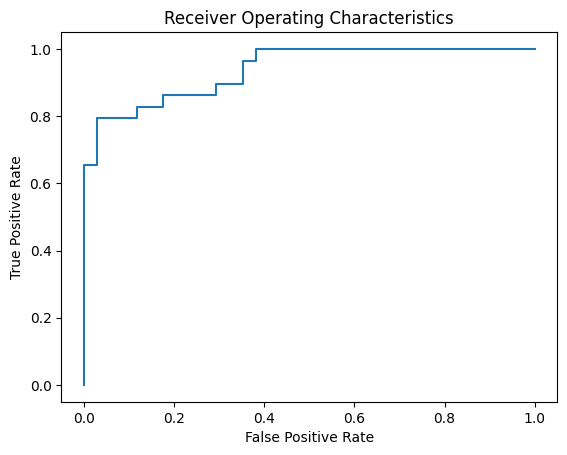

In [15]:
model.eval()
with torch.no_grad():
    # Plot the ROC curve
    y_pred = model(X_test)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    plt.plot(fpr, tpr) # ROC curve = TPR vs FPR
    plt.title("Receiver Operating Characteristics")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<div style="text-align: right"> <font size=6><i class="fa fa-coffee" aria-hidden="true" style="color:#004D7F"></i> </font></div>